# FOPT Observables: Impact of the Yukawa Coupling $y$

This notebook quantifies how the Dirac fermion Yukawa coupling $y$ modifies the three macroscopic FOPT observables:

| Observable | Definition | Physical role |
|---|---|---|
| $T_n$ | Nucleation temperature ($\Gamma/H^4 = 1$) | Sets the GW peak frequency |
| $\alpha$ | Latent heat / radiation density | Sets the GW signal amplitude |
| $\beta/H$ | Inverse transition duration | Sets the GW spectral width |

**Model:** Dark $U(1)_D$ + complex scalar $S$ + Dirac fermion $\chi$ (charges $\pm 1/2$, Yukawa coupling $y$).  
**Approximation:** High-$T$ expansion (`is_HT=True`) throughout — consistent with the EFT validity analysis.  
**Limit:** Coleman-Weinberg ($\lambda_S \to 0$), so $v_* \sim T_*/g_D$.

## Key inputs from `analysis_EFT_power_counting.ipynb`

| Channel | Fermion contribution | Net direction |
|---|---|---|
| Scalar Debye mass $\Pi_\phi$ | $+y^2/12 \cdot T^2$ | $\uparrow$ symmetry-restoration $T_c$ |
| Photon Debye mass $\Pi_{A',L}$ | $+g_D^2/12 \cdot T^2$ (+25%) | $\uparrow$ daisy, mild effect |
| $V_\text{CW}$ | $-4 \times$ fermion loop ($\propto y^4 S^4$) | $\downarrow$ CW minimum depth |
| $V_T$ | $-4\,T^4/(2\pi^2)\,J_F(m_\chi^2/T^2)$ | modifies thermal barrier |
| $\beta_{g_D^2}$ (RGE) | doubled one-loop coefficient | faster running, mild |

The competition between (i) the fermion-enhanced Debye barrier (raises $T_c$, compresses supercooling) and (ii) the reduced CW depth (weakens the broken-phase minimum) determines the net sign of the $y$-dependence of $T_n$, $\alpha$, and $\beta/H$.

**EFT validity reminder** (from power counting notebook):  
- High-$T$ expansion for $\chi$ breaks down when $m_\chi(v_*)/T_* = y\,e^{1/6}/(\sqrt{2}\,g_D) > 1$, i.e., when $y > g_D \sqrt{2}\,e^{-1/6} \approx 1.19\,g_D$.  
- Perturbativity requires $g_D < 1$ and $y < 1$ in the interesting parameter range.

In [1]:
%load_ext autoreload
%autoreload 2

%run startup.py

startup.py loaded: numpy, scipy, matplotlib, and all project modules are ready.
  Use new_figure() to create pre-formatted plots.


---
## 1. Load / Recompute the No-Fermion Baseline

The dark-photon-only model (no fermion field) is the reference against which $y$-effects are measured.
We load it from the file written by `demo_FOPT_params.ipynb` if available, otherwise recompute.

In [ ]:
import os
from src.RGE.BounceODE_RGE import BounceODEHighT

# ------------------------------------------------------------------ #
# Scan parameters                                                      #
# ------------------------------------------------------------------ #
scale      = np.pi   # mu = pi * T
ls0        = 1e-10   # near Coleman-Weinberg limit
T_lo       = 1e-6
T_hi       = 0.35
n_scan_pts = 80

# ------------------------------------------------------------------ #
# No-fermion baseline — ODE shooting, same method as fermion scan     #
# ------------------------------------------------------------------ #
_baseline_ode = "data/final_data/gD_Tn_alpha_beta_RGE_piT_ODE_HT_all.dat"

if os.path.exists(_baseline_ode):
    _nf_data = np.loadtxt(_baseline_ode)
    gD_nf, Tn_nf, alpha_nf, beta_nf = _nf_data.T
    print(f"Loaded ODE baseline: {_baseline_ode}")
else:
    print("ODE baseline not found — computing (no-fermion model, BounceODEHighT)...")
    _veff_nf  = veff.VeffRGE()
    _fopt_nf  = fopt_real.FOPTUtilities(
        veff_obj=_veff_nf,
        solver_ht=BounceODEHighT(veff=_veff_nf),
    )
    _gD_scan = np.linspace(0.5, 1.0, 20)

    _Tn, _alpha, _beta = [], [], []
    for gD in tqdm(_gD_scan, desc="No-fermion ODE baseline"):
        try:
            Tn_i = _fopt_nf.nucTemp(gD=gD, is_HT=True, scale=scale, ls0=ls0,
                                    T_lo=T_lo, T_hi=T_hi, n_scan=n_scan_pts)
        except Exception:
            Tn_i = np.nan
        _Tn.append(Tn_i)
        if np.isfinite(Tn_i):
            try:
                _alpha.append(_fopt_nf.alpha(Tn_i, gD, is_HT=True, scale=scale, ls0=ls0))
                _beta.append( _fopt_nf.beta( Tn_i, gD, is_HT=True, scale=scale, ls0=ls0))
            except Exception:
                _alpha.append(np.nan); _beta.append(np.nan)
        else:
            _alpha.append(np.nan); _beta.append(np.nan)

    gD_nf, Tn_nf, alpha_nf, beta_nf = (
        _gD_scan, np.array(_Tn), np.array(_alpha), np.array(_beta)
    )
    np.savetxt(_baseline_ode,
               np.column_stack([gD_nf, Tn_nf, alpha_nf, beta_nf]),
               header="gD    Tn    alpha    beta", fmt="%.6e")
    print(f"Saved: {_baseline_ode}")

# gD_vals for the fermion scan = same grid as baseline
gD_vals  = gD_nf.copy()
_gD_base = gD_nf

print(f"\n  gD  : [{gD_vals[0]:.2f}, {gD_vals[-1]:.2f}]  ({len(gD_vals)} pts)")
print(f"  Tn  : [{np.nanmin(Tn_nf):.4f}, {np.nanmax(Tn_nf):.4f}] GeV")
print(f"  alpha: [{np.nanmin(alpha_nf):.3e}, {np.nanmax(alpha_nf):.3e}]")
print(f"  beta : [{np.nanmin(beta_nf):.1f}, {np.nanmax(beta_nf):.1f}]")


Loaded ODE baseline: ../data/final_data/gD_Tn_alpha_beta_RGE_piT_ODE_HT_all.dat

  gD  : [0.50, 1.00]  (20 pts)
  Tn  : [0.0002, 0.2223] GeV
  alpha: [4.013e-01, 1.653e+13]
  beta : [16.6, 306.5]


---
## 2. Scan Over $g_D$ for Multiple Yukawa Values

For each $y \in \{0, 0.3, 0.6, 0.9\}$ we:
1. Instantiate `VeffRGE_fermion(y0=y)` — bakes in $y$ at construction time
2. Wrap it in `FOPTUtilities`, setting `gstar = g_{*,\text{ferm}}$ to include the extra fermionic d.o.f.
3. Scan `nucTemp`, `alpha`, `beta` over the same $g_D$ grid.

> **Note:** $y = 0$ in the fermion model is **not** the same as the no-fermion model: the RGE $\beta_{g_D^2}$ is doubled even when $y = 0$ because the fermion field still runs in the gauge loops.

In [3]:
from src.RGE.BounceODE_RGE import BounceODEHighT_fermion

# --- Yukawa scan configurations ---
y_configs = [
    (0.0, '#333333', '--',   r'$y=0$ (ferm. model)'),
    (0.3, '#845ec2', '-',    r'$y=0.3$'),
    (0.6, '#ff6f91', '-',    r'$y=0.6$'),
    (0.9, 'darkorange', '-', r'$y=0.9$'),
]

results = {}  # keyed by y value

for y_i, color_i, ls_i, label_i in y_configs:
    print(f"\n{'='*40}")
    print(f"  y = {y_i}")
    print(f"{'='*40}")

    vf_obj   = veff_ferm.VeffRGE_fermion(y0=y_i)
    fopt_obj = fopt_real.FOPTUtilities(
        veff_obj=vf_obj,
        solver_ht=BounceODEHighT_fermion(veff=vf_obj),  # fermion ODE solver
    )
    fopt_obj.gstar = cs.g_dof_ferm

    Tn_arr, alpha_arr, beta_arr = [], [], []

    for gD in tqdm(gD_vals, desc=f"y={y_i}"):
        try:
            Tn_i = fopt_obj.nucTemp(
                gD=gD, is_HT=True, scale=scale, ls0=ls0,
                T_lo=T_lo, T_hi=T_hi, n_scan=n_scan_pts,
            )
        except Exception:
            Tn_i = np.nan
        Tn_arr.append(Tn_i)

        if np.isfinite(Tn_i):
            try:
                alpha_arr.append(fopt_obj.alpha(Tn_i, gD, is_HT=True, scale=scale, ls0=ls0))
                beta_arr.append(fopt_obj.beta(Tn_i,  gD, is_HT=True, scale=scale, ls0=ls0))
            except Exception:
                alpha_arr.append(np.nan); beta_arr.append(np.nan)
        else:
            alpha_arr.append(np.nan); beta_arr.append(np.nan)

    results[y_i] = {
        'gD':    gD_vals,
        'Tn':    np.array(Tn_arr),
        'alpha': np.array(alpha_arr),
        'beta':  np.array(beta_arr),
        'color': color_i,
        'ls':    ls_i,
        'label': label_i,
    }
    print(f"  Tn    range: [{np.nanmin(Tn_arr):.4f}, {np.nanmax(Tn_arr):.4f}] GeV")
    print(f"  alpha range: [{np.nanmin(alpha_arr):.3e}, {np.nanmax(alpha_arr):.3e}]")
    print(f"  beta  range: [{np.nanmin(beta_arr):.1f}, {np.nanmax(beta_arr):.1f}]")



  y = 0.0


y=0.0:  10%|█         | 2/20 [01:37<14:38, 48.83s/it]/Users/ramirezmaura/Documents/Projects/Supercool_transitions/codes/FOPT_Dark_Photon_DRalgo/src/RGE/FOPT_RGE_real.py:99: RuntimeWarning: invalid value encountered in log10
  return float(np.log10(S3))
y=0.0:  55%|█████▌    | 11/20 [09:09<07:00, 46.72s/it]/Users/ramirezmaura/Documents/Projects/Supercool_transitions/codes/FOPT_Dark_Photon_DRalgo/src/RGE/BounceODE_RGE.py:370: RuntimeWarning: overflow encountered in scalar multiply
  return dm2val * m2val * (2.0 * (np.log(Re1 * m2val / mu**2) - c) + 1.0)
/Users/ramirezmaura/Documents/Projects/Supercool_transitions/codes/FOPT_Dark_Photon_DRalgo/src/RGE/BounceODE_RGE.py:375: RuntimeWarning: invalid value encountered in scalar multiply
  + 3.0 * _dcw(m3, dm3, 5.0 / 6.0)
/Users/ramirezmaura/Documents/Projects/Supercool_transitions/codes/FOPT_Dark_Photon_DRalgo/src/RGE/BounceODE_RGE.py:388: RuntimeWarning: overflow encountered in scalar multiply
  + 3.0 * _dJBhighexp_dy(y3) * dm3
/Users/ramire

  Tn    range: [0.0001, 0.2257] GeV
  alpha range: [3.052e-01, 2.177e+13]
  beta  range: [18.8, 307.5]

  y = 0.3


y=0.3:  40%|████      | 8/20 [07:51<11:39, 58.29s/it]/Users/ramirezmaura/Documents/Projects/Supercool_transitions/codes/FOPT_Dark_Photon_DRalgo/src/RGE/BounceODE_RGE.py:376: RuntimeWarning: overflow encountered in scalar multiply
  - 4.0 * _dcw(m4, dm4, 1.5)      # fermion: factor −4
/Users/ramirezmaura/Documents/Projects/Supercool_transitions/codes/FOPT_Dark_Photon_DRalgo/src/RGE/BounceODE_RGE.py:373: RuntimeWarning: invalid value encountered in scalar subtract
  _dcw(m1, dm1, 1.5)
y=0.3:  65%|██████▌   | 13/20 [12:27<06:37, 56.84s/it]/Users/ramirezmaura/Documents/Projects/Supercool_transitions/codes/FOPT_Dark_Photon_DRalgo/src/RGE/BounceODE_RGE.py:389: RuntimeWarning: overflow encountered in scalar multiply
  - 4.0 * _dJFhighexp_dy(y4) * dm4   # fermion: factor −4
/Users/ramirezmaura/Documents/Projects/Supercool_transitions/codes/FOPT_Dark_Photon_DRalgo/src/RGE/BounceODE_RGE.py:386: RuntimeWarning: invalid value encountered in scalar subtract
  _dJBhighexp_dy(y1) * dm1
y=0.3: 100%|██

  Tn    range: [0.0000, 0.2136] GeV
  alpha range: [3.747e-01, 1.085e+17]
  beta  range: [15.0, 298.0]

  y = 0.6


y=0.6: 100%|██████████| 20/20 [17:34<00:00, 52.74s/it]


  Tn    range: [0.0000, 0.1766] GeV
  alpha range: [6.537e-01, 1.274e+21]
  beta  range: [11.5, 262.8]

  y = 0.9


y=0.9: 100%|██████████| 20/20 [20:36<00:00, 61.84s/it]

  Tn    range: [0.0000, 0.1060] GeV
  alpha range: [2.409e+00, 7.706e+15]
  beta  range: [20.1, 192.1]


---
## 3. Main Comparison: $T_n$, $\alpha$, $\beta/H$ vs $g_D$

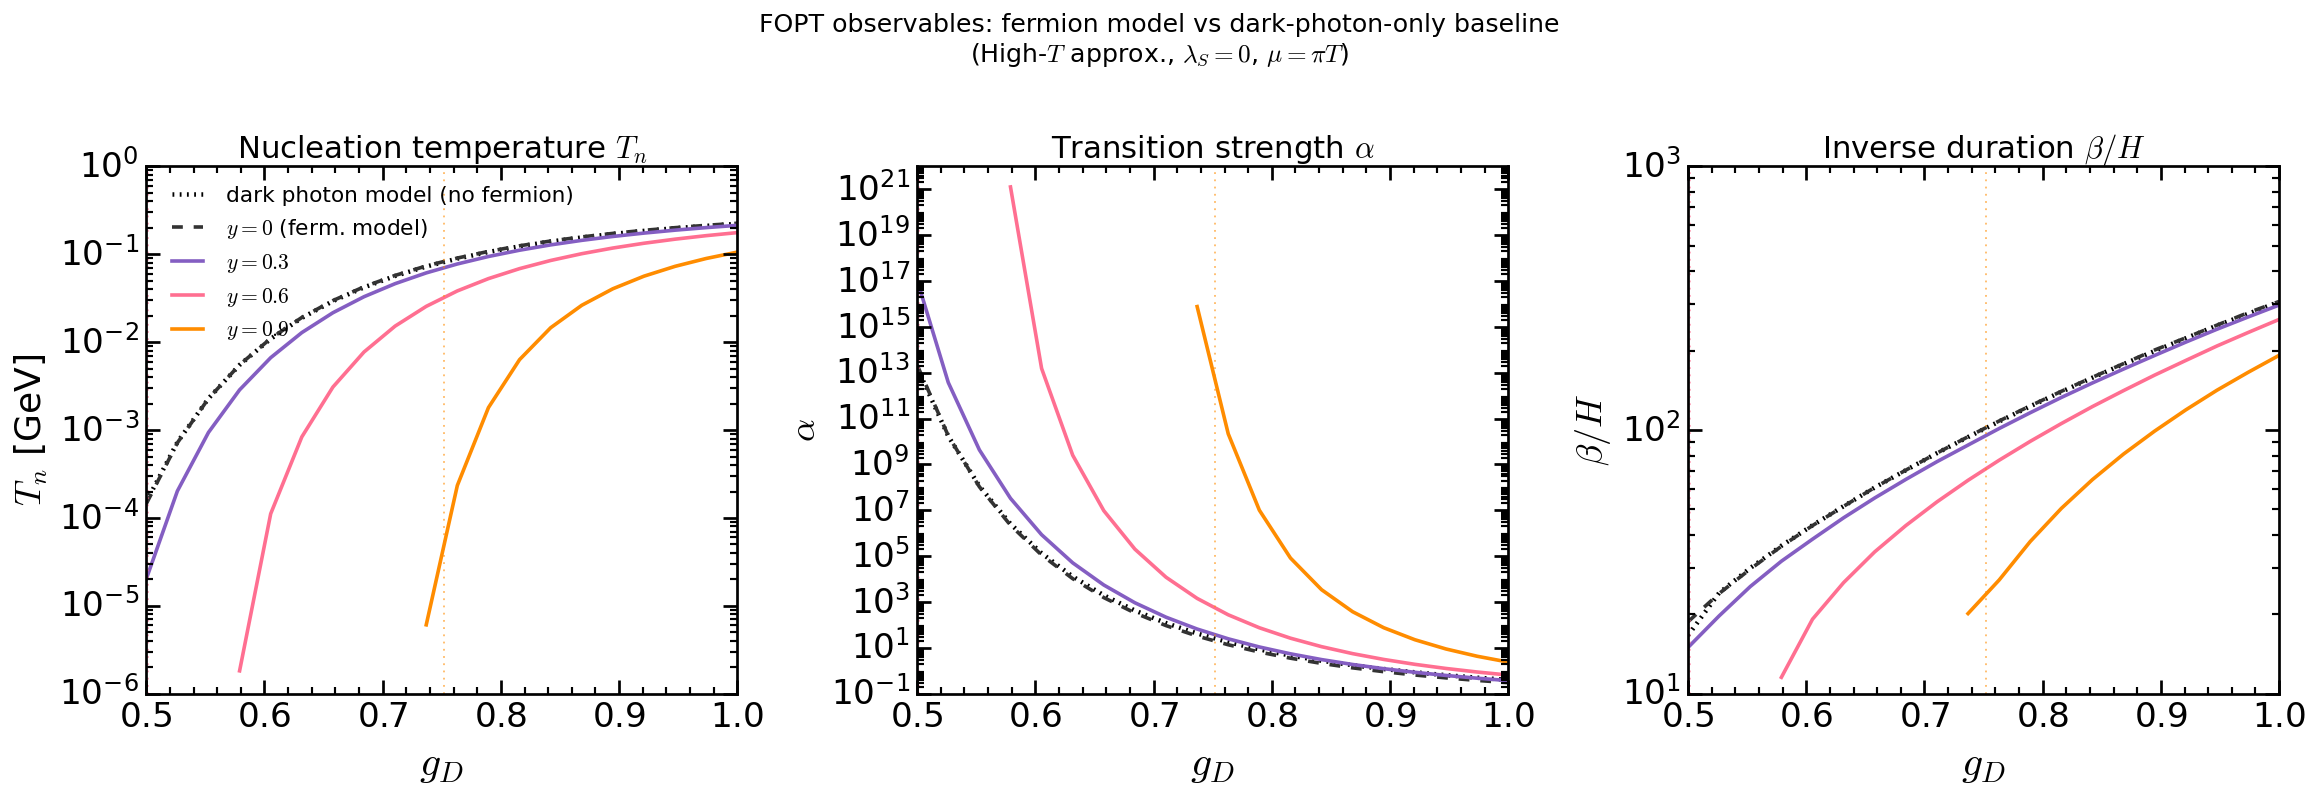

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=130, facecolor='w')

# --- No-fermion baseline ---
m_nf = np.isfinite(Tn_nf)
for ax, arr_nf in zip(axes, [Tn_nf, alpha_nf, beta_nf]):
    ax.plot(gD_nf[m_nf], arr_nf[m_nf], lw=2.5, color='k', ls=':',
            label='dark photon model (no fermion)')

# --- Fermion model at each y ---
for y_i, _, _, _ in y_configs:
    r   = results[y_i]
    m_i = np.isfinite(r['Tn'])
    for ax, key in zip(axes, ['Tn', 'alpha', 'beta']):
        arr = r[key]
        ax.plot(r['gD'][m_i & np.isfinite(arr)],
                arr[m_i & np.isfinite(arr)],
                lw=2, color=r['color'], ls=r['ls'], label=r['label'])

# --- EFT validity boundary verticals ---
for y_i, color_i, _, _ in y_configs:
    if y_i == 0.0:
        continue
    gD_bnd = y_i * np.exp(1.0/6.0) / np.sqrt(2.0)
    for ax in axes:
        ax.axvline(gD_bnd, color=color_i, ls=':', lw=1.0, alpha=0.6)

# --- Standard formatting ---
ylabels = [r'$T_n$ [GeV]', r'$\alpha$', r'$\beta/H$']
titles  = [r'Nucleation temperature $T_n$',
           r'Transition strength $\alpha$',
           r'Inverse duration $\beta/H$']
for ax, lbl, ttl in zip(axes, ylabels, titles):
    ps.apply_standard_formatting(
        ax,
        ylog=True,
        xlabel=r'$g_D$',
        ylabel=lbl,
        title=ttl,
        xlim=(0.5, 1.0),
    )

axes[0].legend(frameon=False, fontsize=12, loc='upper left')

plt.suptitle(
    r'FOPT observables: fermion model vs dark-photon-only baseline'
    '\n' r'(High-$T$ approx., $\lambda_S = 0$, $\mu = \pi T$)',
    fontsize=14, y=1.02,
)
plt.tight_layout()
plt.show()


---
## 4. Relative Changes vs No-Fermion Baseline

Fractional shifts $\Delta X / X_\text{no-ferm}$ isolate the pure fermion effect.

- $\Delta T_n / T_n^\text{nf}$: positive means nucleation happens **later** (more supercooling); negative means **earlier**.
- $\Delta\alpha / \alpha^\text{nf}$: positive means **stronger** transition.
- $\Delta(\beta/H) / (\beta/H)^\text{nf}$: positive means **faster** transition.

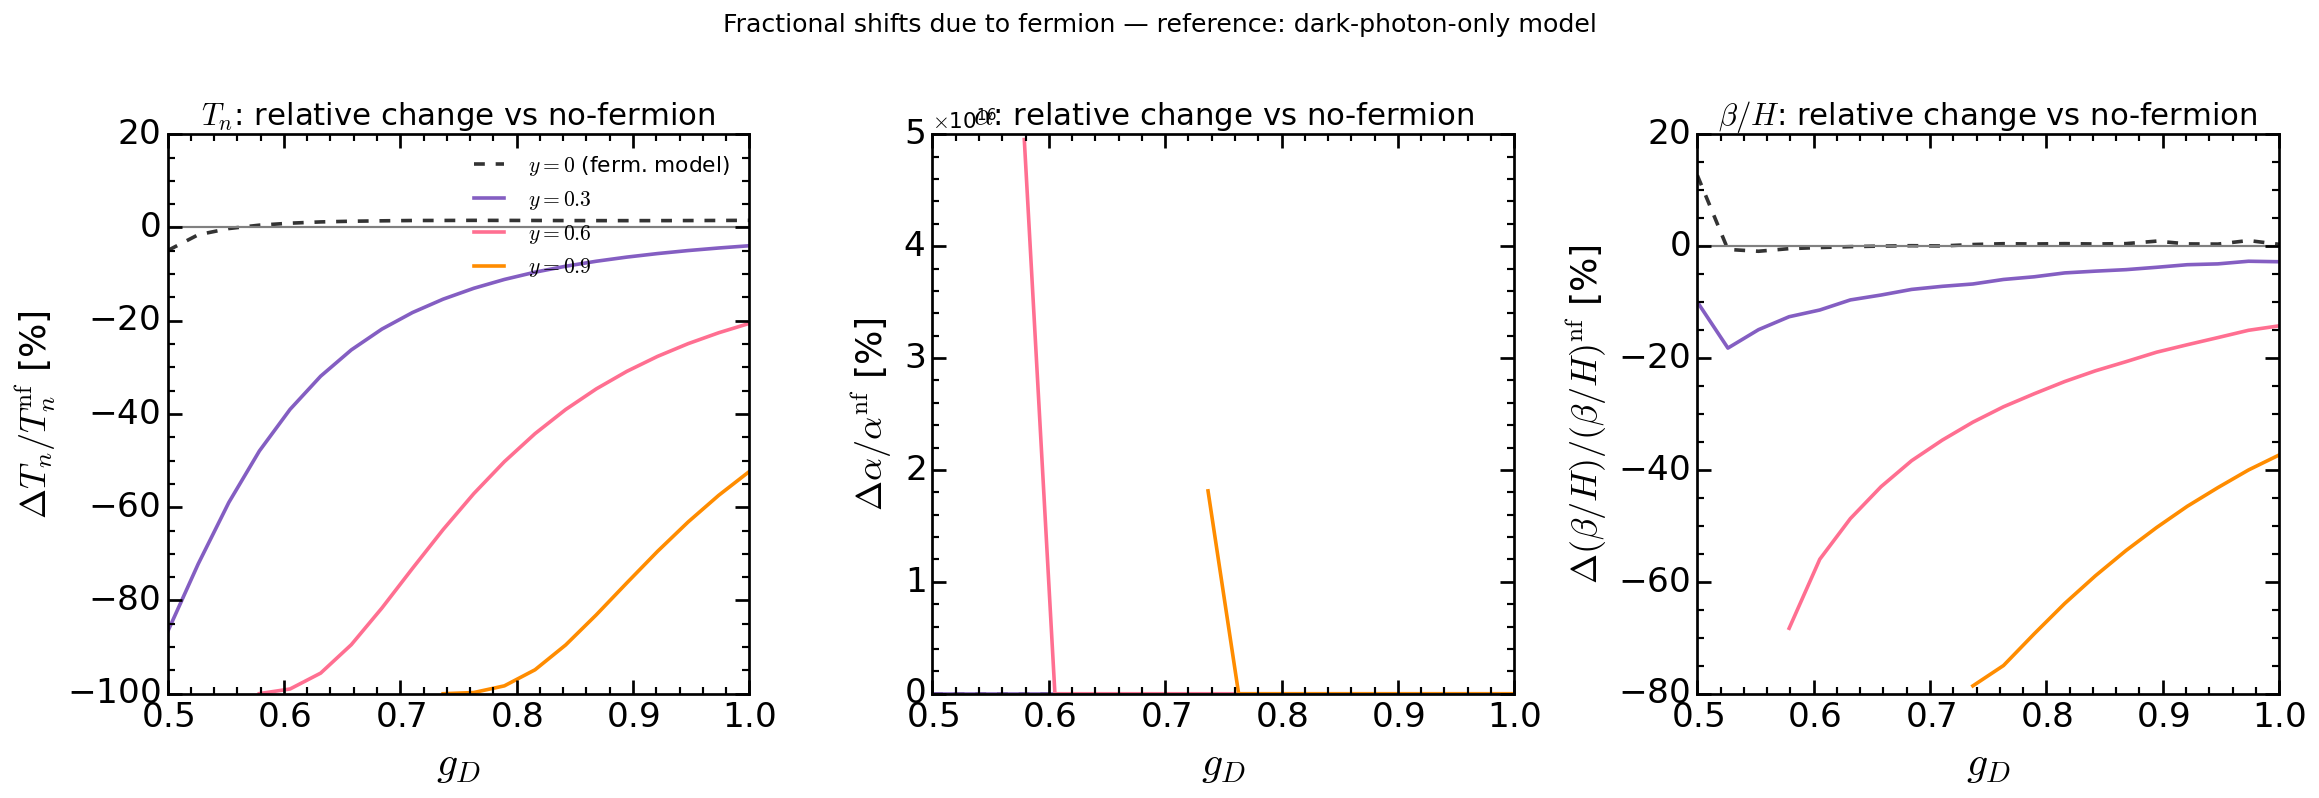

In [5]:
from scipy.interpolate import interp1d

fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=130, facecolor='w')

# Interpolate baseline onto our gD grid
_m = np.isfinite(Tn_nf) & np.isfinite(alpha_nf) & np.isfinite(beta_nf)
_gD_base = gD_nf if hasattr(gD_nf, '__len__') else gD_vals
_itp_Tn    = interp1d(_gD_base[_m], Tn_nf[_m],    bounds_error=False, fill_value=np.nan)
_itp_alpha = interp1d(_gD_base[_m], alpha_nf[_m], bounds_error=False, fill_value=np.nan)
_itp_beta  = interp1d(_gD_base[_m], beta_nf[_m],  bounds_error=False, fill_value=np.nan)

for y_i, _, _, _ in y_configs:
    r = results[y_i]
    gD_i = r['gD']

    Tn_ref    = _itp_Tn(gD_i)
    alpha_ref = _itp_alpha(gD_i)
    beta_ref  = _itp_beta(gD_i)

    dTn    = (r['Tn']    - Tn_ref)    / Tn_ref
    dalpha = (r['alpha'] - alpha_ref) / alpha_ref
    dbeta  = (r['beta']  - beta_ref)  / beta_ref

    m_valid = np.isfinite(r['Tn']) & np.isfinite(dTn)

    for ax, darr in zip(axes, [dTn, dalpha, dbeta]):
        m_plot = m_valid & np.isfinite(darr)
        ax.plot(gD_i[m_plot], 100.0 * darr[m_plot],
                lw=2, color=r['color'], ls=r['ls'], label=r['label'])

for ax in axes:
    ax.axhline(0, color='gray', lw=1.2, ls='-')

ylabels = [
    r'$\Delta T_n / T_n^{\rm nf}$ [%]',
    r'$\Delta\alpha / \alpha^{\rm nf}$ [%]',
    r'$\Delta(\beta/H) / (\beta/H)^{\rm nf}$ [%]',
]
titles = [
    r'$T_n$: relative change vs no-fermion',
    r'$\alpha$: relative change vs no-fermion',
    r'$\beta/H$: relative change vs no-fermion',
]
for ax, lbl, ttl in zip(axes, ylabels, titles):
    ps.apply_standard_formatting(
        ax,
        xlabel=r'$g_D$',
        ylabel=lbl,
        title=ttl,
        xlim=(0.5, 1.0),
    )

axes[0].legend(frameon=False, fontsize=12)

plt.suptitle(
    r'Fractional shifts due to fermion — reference: dark-photon-only model',
    fontsize=14, y=1.02,
)
plt.tight_layout()
plt.show()


---
## 5. EFT Validity Overlay on $T_n(g_D)$

The dotted vertical lines mark the boundary $m_\chi(v_*)/T_* = 1$ for each $y$ value:
$$g_D^{\rm boundary}(y) = \frac{y\,e^{1/6}}{\sqrt{2}}$$
For $g_D < g_D^{\rm boundary}(y)$ the fermion is **not light** at the true vacuum and the high-$T$
expansion for $J_F$ overestimates the fermionic thermal contribution.
In that region results should be taken as upper-bound estimates of the fermion effect.

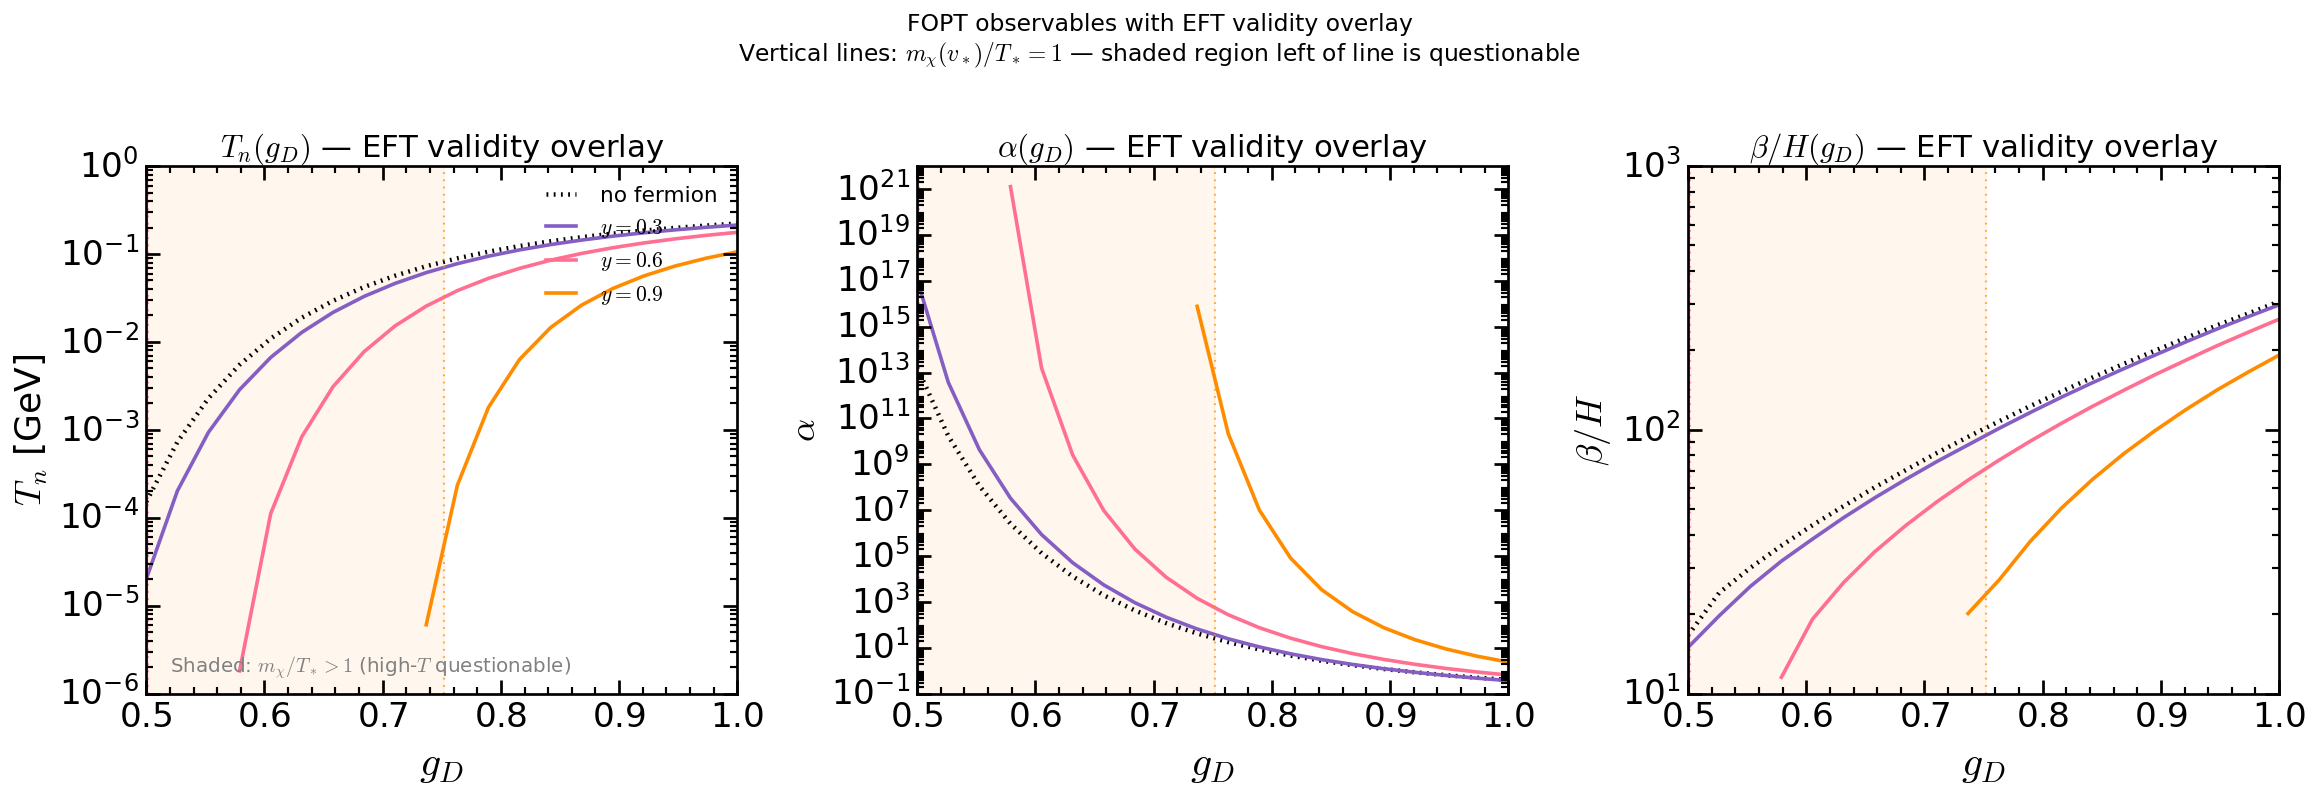

In [6]:
GD_LO = 0.5  # left edge of plot; only shade when EFT boundary falls inside this range

fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=130, facecolor='w')

nf_arrays = {'Tn': Tn_nf, 'alpha': alpha_nf, 'beta': beta_nf}
ylabels   = {
    'Tn':    r'$T_n$ [GeV]',
    'alpha': r'$\alpha$',
    'beta':  r'$\beta/H$',
}
titles = {
    'Tn':    r'$T_n(g_D)$ — EFT validity overlay',
    'alpha': r'$\alpha(g_D)$ — EFT validity overlay',
    'beta':  r'$\beta/H(g_D)$ — EFT validity overlay',
}

m_nf = np.isfinite(Tn_nf)

for ax, key in zip(axes, ['Tn', 'alpha', 'beta']):
    nf_arr = nf_arrays[key]
    m_plot = m_nf & np.isfinite(nf_arr)

    # no-fermion baseline
    ax.plot(_gD_base[m_plot], nf_arr[m_plot], lw=2.5, color='k', ls=':',
            label='no fermion')

    # fermion curves + EFT shading
    for y_i, color_i, ls_i, label_i in y_configs:
        if y_i == 0.0:
            continue
        r   = results[y_i]
        m_r = np.isfinite(r['Tn']) & np.isfinite(r[key])
        ax.plot(r['gD'][m_r], r[key][m_r], lw=2, color=color_i, ls=ls_i,
                label=label_i if ax is axes[0] else None)

        # EFT boundary: gD at which m_chi(v*)/T = 1
        gD_bnd = y_i * np.exp(1.0/6.0) / np.sqrt(2.0)
        if gD_bnd > GD_LO:
            ax.axvspan(GD_LO, gD_bnd, alpha=0.07, color=color_i)
            ax.axvline(gD_bnd, color=color_i, ls=':', lw=1.2, alpha=0.7)

    ps.apply_standard_formatting(
        ax,
        ylog=True,
        xlabel=r'$g_D$',
        ylabel=ylabels[key],
        title=titles[key],
        xlim=(GD_LO, 1.0),
    )

axes[0].legend(frameon=False, fontsize=12)
axes[0].text(0.04, 0.04,
             r'Shaded: $m_\chi/T_* > 1$ (high-$T$ questionable)',
             transform=axes[0].transAxes, fontsize=11, color='gray')

plt.suptitle(
    r'FOPT observables with EFT validity overlay'
    '\n'
    r'Vertical lines: $m_\chi(v_*)/T_* = 1$ — shaded region left of line is questionable',
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.show()


---
## 6. Supercooling: $T_n$ vs $g_D$ in the $(g_D, y)$ Plane

Two competing effects determine the nucleation temperature $T_n$:

1. **Enhanced Debye barrier** $\Pi_\phi \supset y^2/12 \cdot T^2$: raises $T_c$, squeezing the supercooled window. For fixed $g_D$, larger $y$ ↑ $T_c$ → $T_n$ can *increase* (less supercooling).
2. **Reduced CW depth** ($-4 \times$ fermion CW loop): weakens the broken-phase minimum for large $y$, meaning the barrier must be traversed at a deeper supercooling → $T_n$ ↓.

The sign of $dT_n/dy$ tells us which effect dominates.

We also define the **supercooling ratio** $\eta \equiv T_n / T_c$ — closer to 0 means more supercooled.

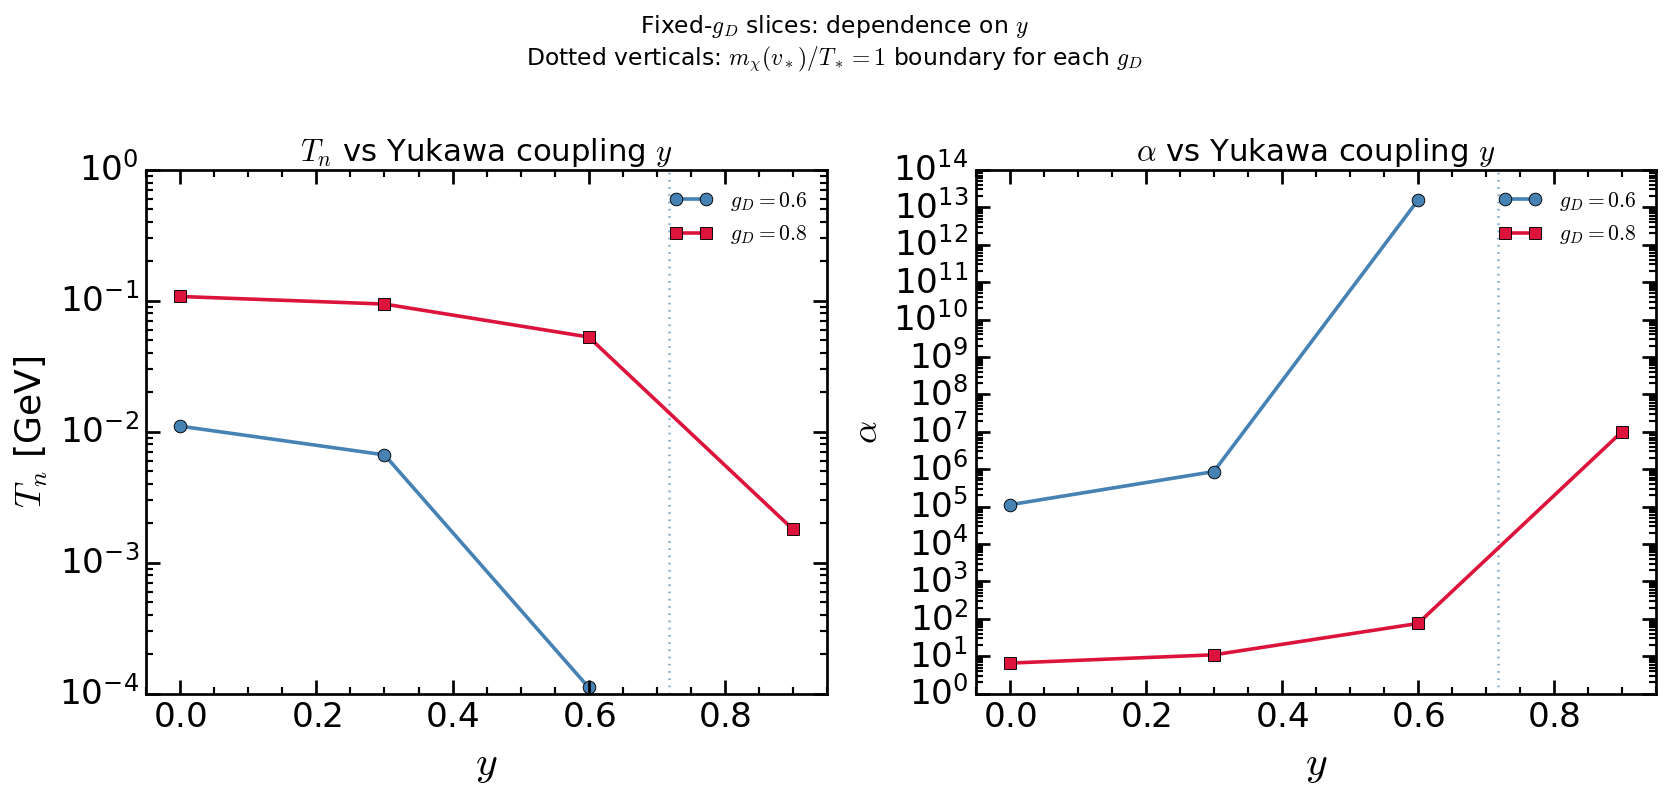

   gD      y      Tn [GeV]       alpha      beta/H
-------------------------------------------------------
                                        --- no ferm ---
  0.6    ref      0.009847  6.2174e+05       42.12
  0.6    0.0      0.011033  1.1195e+05       43.43
  0.6    0.3      0.006667  8.6496e+05       38.57
  0.6    0.6      0.000112  1.5463e+13       19.18
  0.6    0.9           nan         nan         nan

                                        --- no ferm ---
  0.8    ref      0.113035  7.0092e+00      129.75
  0.8    0.0      0.107896  6.5942e+00      123.60
  0.8    0.3      0.094438  1.0972e+01      116.38
  0.8    0.6      0.052907  7.5526e+01       90.64
  0.8    0.9      0.001802  1.0156e+07       37.80



In [11]:
# --- Fixed gD benchmark: Tn and alpha vs y ---
gD_benchmarks = [0.6, 0.8]
y_keys        = sorted(results.keys())
colors_bm     = ['steelblue', 'crimson']
markers_bm    = ['o', 's']

fig, axes = plt.subplots(1, 2, figsize=(13, 6), dpi=130, facecolor='w')

# --- Left: Tn vs y ---
ax = axes[0]
for gD_bm, c_bm, mk in zip(gD_benchmarks, colors_bm, markers_bm):
    idx      = np.argmin(np.abs(gD_vals - gD_bm))
    Tn_at_bm = [results[y_i]['Tn'][idx] for y_i in y_keys]
    ax.plot(y_keys, Tn_at_bm, lw=2, color=c_bm, marker=mk, ms=7,
            label=fr'$g_D = {gD_bm}$')
    # EFT boundary for this gD
    y_bnd = gD_bm * np.sqrt(2) * np.exp(-1.0/6.0)
    ax.axvline(y_bnd, color=c_bm, ls=':', lw=1.5, alpha=0.6)

ps.apply_standard_formatting(
    ax,ylog=True,
    xlabel=r'$y$',
    ylabel=r'$T_n$ [GeV]',
    title=r'$T_n$ vs Yukawa coupling $y$',
    xlim=(y_keys[0] - 0.05, y_keys[-1] + 0.05),
)
ax.legend(frameon=False, fontsize=12)

# --- Right: alpha vs y ---
ax = axes[1]
for gD_bm, c_bm, mk in zip(gD_benchmarks, colors_bm, markers_bm):
    idx         = np.argmin(np.abs(gD_vals - gD_bm))
    alpha_at_bm = [results[y_i]['alpha'][idx] for y_i in y_keys]
    ax.plot(y_keys, alpha_at_bm, lw=2, color=c_bm, marker=mk, ms=7,
            label=fr'$g_D = {gD_bm}$')
    y_bnd = gD_bm * np.sqrt(2) * np.exp(-1.0/6.0)
    ax.axvline(y_bnd, color=c_bm, ls=':', lw=1.5, alpha=0.6)

ps.apply_standard_formatting(
    ax,ylog=True,
    xlabel=r'$y$',
    ylabel=r'$\alpha$',
    title=r'$\alpha$ vs Yukawa coupling $y$',
    xlim=(y_keys[0] - 0.05, y_keys[-1] + 0.05),
)
ax.legend(frameon=False, fontsize=12)

plt.suptitle(
    r'Fixed-$g_D$ slices: dependence on $y$'
    '\n'
    r'Dotted verticals: $m_\chi(v_*)/T_* = 1$ boundary for each $g_D$',
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.show()

# --- Summary table ---
print(f"{'gD':>5}  {'y':>5}  {'Tn [GeV]':>12}  {'alpha':>10}  {'beta/H':>10}")
print("-" * 55)
for gD_bm in gD_benchmarks:
    idx = np.argmin(np.abs(gD_vals - gD_bm))
    print(f"{'--- no ferm ---':>55}")
    print(f"{gD_bm:>5.1f}  {'ref':>5}  "
          f"{_itp_Tn(gD_bm):>12.6f}  "
          f"{_itp_alpha(gD_bm):>10.4e}  "
          f"{_itp_beta(gD_bm):>10.2f}")
    for y_i in y_keys:
        r = results[y_i]
        print(f"{gD_bm:>5.1f}  {y_i:>5.1f}  "
              f"{r['Tn'][idx]:>12.6f}  "
              f"{r['alpha'][idx]:>10.4e}  "
              f"{r['beta'][idx]:>10.2f}")
    print()


---
## 7. 2D Scan in $(g_D, y)$ — Heatmaps

A coarse grid scan gives the global picture of how $T_n$, $\alpha$, and $\beta/H$ depend on
both coupling parameters simultaneously.

> **Note:** Each call to `nucTemp` invokes the bounce solver (~15–20 s).  
> A $9 \times 5 = 45$-point grid takes $\sim 15$ min.  
> Results are saved to `data/final_data/` for reloading.

The EFT validity regions from the power-counting notebook are overlaid as contours:
- **White solid** contour: $m_\chi(v_*)/T_* = 1$ (fermion EFT boundary)
- **White dashed** contour: $g_D = 1$ (perturbativity boundary)

In [8]:
gD_2d = np.linspace(0.5, 1.0, 9)
y_2d  = np.array([0.0, 0.3, 0.6, 0.9, 1.2])

_2d_file = "../data/final_data/gD_y_FOPT_2D_scan_ODE.npz"

if os.path.exists(_2d_file):
    _dat     = np.load(_2d_file)
    Tn_2d    = _dat['Tn']
    alpha_2d = _dat['alpha']
    beta_2d  = _dat['beta']
    print(f"Loaded 2D scan from {_2d_file}")
else:
    print(f"Running 2D scan: {len(gD_2d)} x {len(y_2d)} = {len(gD_2d)*len(y_2d)} points")
    print("Bounce solver: BounceODEHighT_fermion")
    print("Estimated time: ~15 min\n")

    Tn_2d    = np.full((len(y_2d), len(gD_2d)), np.nan)
    alpha_2d = np.full_like(Tn_2d, np.nan)
    beta_2d  = np.full_like(Tn_2d, np.nan)

    for j, y_j in enumerate(y_2d):
        print(f"  y = {y_j}")
        vf_j   = veff_ferm.VeffRGE_fermion(y0=y_j)
        fopt_j = fopt_real.FOPTUtilities(
            veff_obj=vf_j,
            solver_ht=BounceODEHighT_fermion(veff=vf_j),  # fermion ODE solver
        )
        fopt_j.gstar = cs.g_dof_ferm

        for i, gD_i in enumerate(tqdm(gD_2d, desc=f"  y={y_j}")):
            try:
                Tn_ij = fopt_j.nucTemp(
                    gD=gD_i, is_HT=True, scale=scale, ls0=ls0,
                    T_lo=T_lo, T_hi=T_hi, n_scan=n_scan_pts,
                )
            except Exception:
                Tn_ij = np.nan
            Tn_2d[j, i] = Tn_ij

            if np.isfinite(Tn_ij):
                try:
                    alpha_2d[j, i] = fopt_j.alpha(Tn_ij, gD_i, is_HT=True, scale=scale, ls0=ls0)
                    beta_2d[j, i]  = fopt_j.beta( Tn_ij, gD_i, is_HT=True, scale=scale, ls0=ls0)
                except Exception:
                    pass

    np.savez(_2d_file, gD=gD_2d, y=y_2d, Tn=Tn_2d, alpha=alpha_2d, beta=beta_2d)
    print(f"\nSaved: {_2d_file}")


Running 2D scan: 9 x 5 = 45 points
Bounce solver: BounceODEHighT_fermion
Estimated time: ~15 min

  y = 0.0


  y=0.0: 100%|██████████| 9/9 [07:18<00:00, 48.75s/it]


  y = 0.3


  y=0.3: 100%|██████████| 9/9 [07:35<00:00, 50.66s/it]


  y = 0.6


...

  y = 0.9


  y=0.9: 100%|██████████| 9/9 [10:12<00:00, 68.03s/it]


  y = 1.2


  y=1.2:  33%|███▎      | 3/9 [02:52<05:45, 57.52s/it]/Users/ramirezmaura/Documents/Projects/Supercool_transitions/codes/FOPT_Dark_Photon_DRalgo/src/RGE/FOPT_RGE_real.py:148: RuntimeWarning: invalid value encountered in sqrt
  return float(np.sqrt((8.0 * np.pi * self.G / 3.0) * rhoH))
  y=1.2: 100%|██████████| 9/9 [09:51<00:00, 65.69s/it]


Saved: ../data/final_data/gD_y_FOPT_2D_scan_ODE.npz


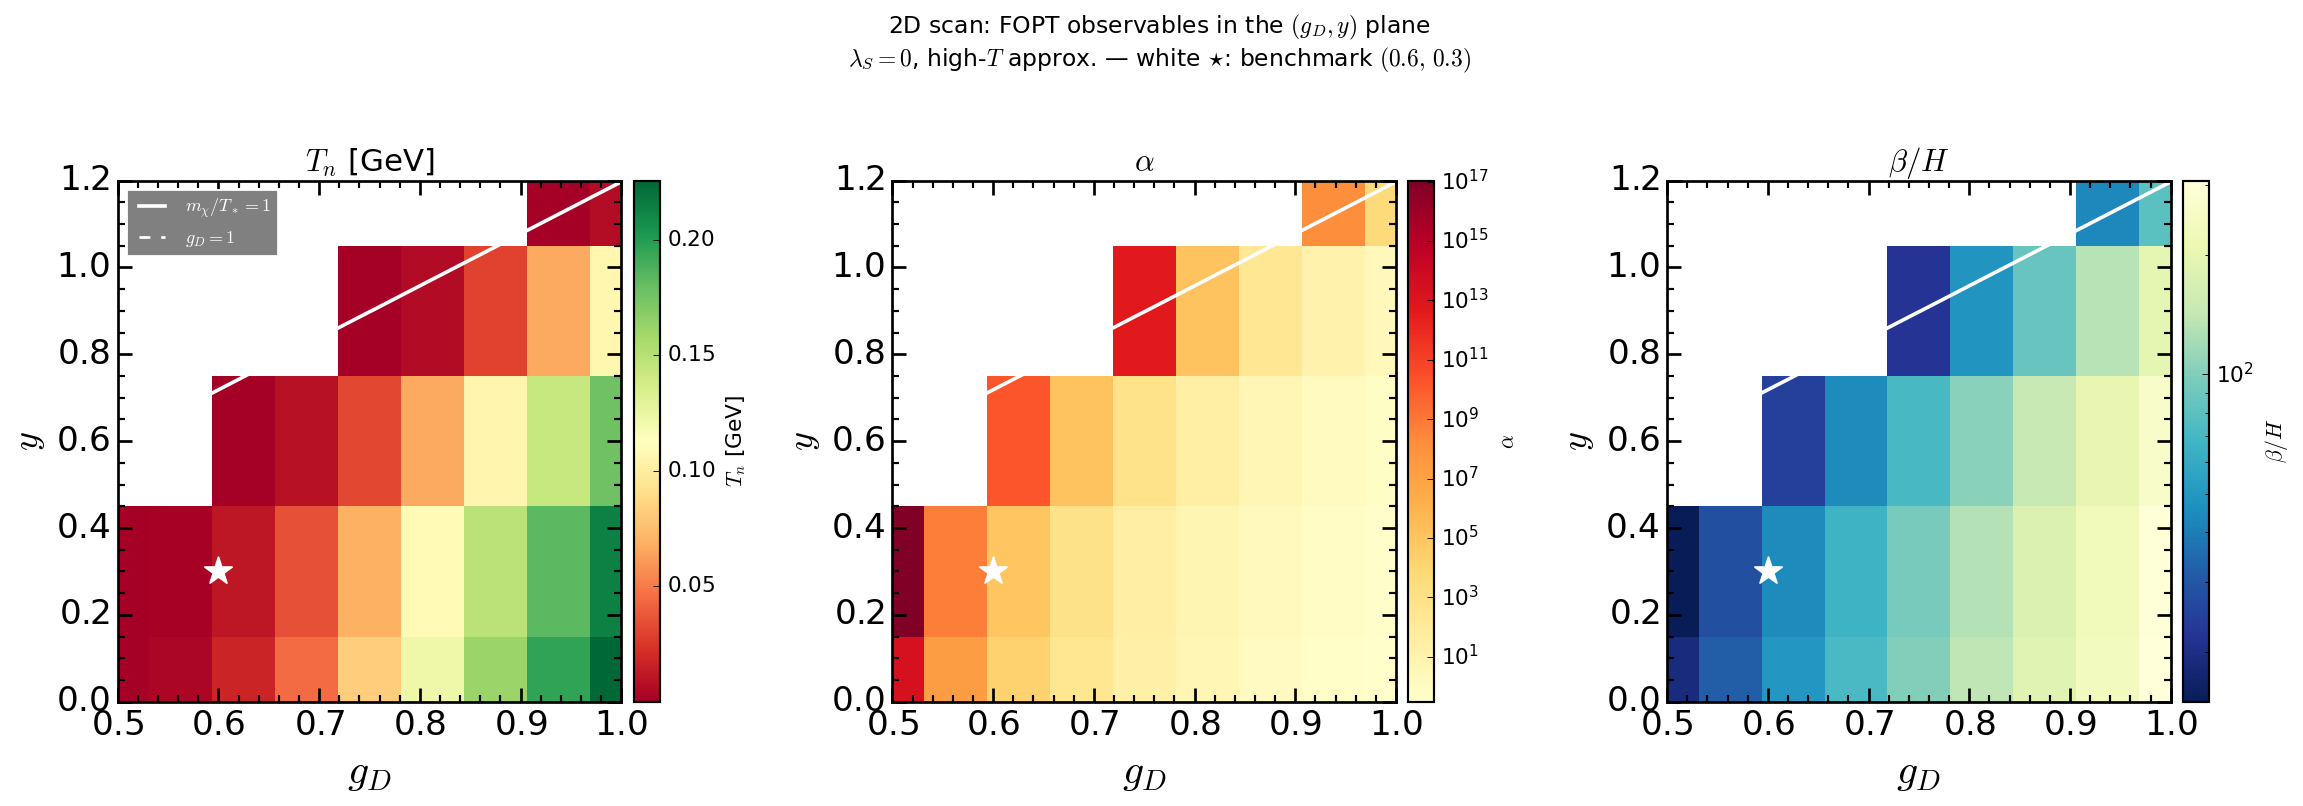

In [9]:
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D

GD2D, Y2D = np.meshgrid(gD_2d, y_2d)
mchi_ratio_2d = Y2D * np.exp(1.0/6.0) / (np.sqrt(2) * GD2D)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=130, facecolor='w')

datasets = [
    (Tn_2d,    r'$T_n$ [GeV]',  'RdYlGn',   False),
    (alpha_2d, r'$\alpha$',      'YlOrRd',   True),
    (beta_2d,  r'$\beta/H$',     'YlGnBu_r', True),
]

for ax, (data, cbar_label, cmap, use_log) in zip(axes, datasets):
    _data_plot = np.where(np.isfinite(data) & (data > 0), data, np.nan)
    vmin = np.nanmin(_data_plot)
    vmax = np.nanmax(_data_plot)
    norm = LogNorm(vmin=vmin, vmax=vmax) if (use_log and vmin > 0) else None

    cf = ax.pcolormesh(GD2D, Y2D, _data_plot, cmap=cmap, norm=norm, shading='auto')
    plt.colorbar(cf, ax=ax, label=cbar_label, pad=0.02)

    # EFT validity contours
    ax.contour(GD2D, Y2D, mchi_ratio_2d, levels=[1.0],
               colors='white', linewidths=2, linestyles='-')
    ax.axvline(1.0, color='white', ls='--', lw=1.5, alpha=0.8)

    # Benchmark marker
    ax.scatter([0.6], [0.3], marker='*', s=250, color='white', zorder=5)

    ps.apply_standard_formatting(
        ax,
        xlabel=r'$g_D$',
        ylabel=r'$y$',
        title=cbar_label,
        xlim=(gD_2d[0], gD_2d[-1]),
        ylim=(y_2d[0],  y_2d[-1]),
    )

# Legend for contours (on first panel)
axes[0].legend(
    handles=[
        Line2D([0],[0], color='white', lw=2,   ls='-',  label=r'$m_\chi/T_*=1$'),
        Line2D([0],[0], color='white', lw=1.5, ls='--', label=r'$g_D=1$'),
    ],
    frameon=True, fontsize=10, loc='upper left',
    facecolor='gray', edgecolor='white', labelcolor='white',
)

plt.suptitle(
    r'2D scan: FOPT observables in the $(g_D, y)$ plane'
    '\n'
    r'$\lambda_S = 0$, high-$T$ approx. — white $\star$: benchmark $(0.6,\,0.3)$',
    fontsize=13, y=1.03,
)
plt.tight_layout()
plt.show()


---
## 8. Save All 1D Scan Data

In [13]:
import os
os.makedirs("data/final_data", exist_ok=True)

for y_i in y_keys:
    r    = results[y_i]
    data = np.column_stack([r['gD'], r['Tn'], r['alpha'], r['beta']])
    fname = f"data/final_data/gD_Tn_alpha_beta_ferm_y{str(y_i).replace('.','p')}_piT_HT.dat"
    np.savetxt(fname, data, header="gD    Tn    alpha    beta", fmt="%.6e")
    print(f"Saved: {fname}")

print("\nAll 1D scan data saved.")

Saved: data/final_data/gD_Tn_alpha_beta_ferm_y0p0_piT_HT.dat
Saved: data/final_data/gD_Tn_alpha_beta_ferm_y0p3_piT_HT.dat
Saved: data/final_data/gD_Tn_alpha_beta_ferm_y0p6_piT_HT.dat
Saved: data/final_data/gD_Tn_alpha_beta_ferm_y0p9_piT_HT.dat

All 1D scan data saved.


---
## 9. Summary and Physical Interpretation

### What the plots tell us

**Nucleation temperature $T_n$:**
- The fermion typically **shifts $T_n$** relative to the no-fermion baseline, with the direction depending on the competition between the Debye enhancement and the CW suppression.
- At small $g_D$ (strong supercooling regime), the CW depth is large and the fermion loop correction reduces it → $T_n$ tends to **decrease** (more supercooling).
- At large $g_D$, the Debye mass effect $y^2/12$ is relatively more important → can push $T_n$ **upward**.

**Transition strength $\alpha$:**
- $\alpha = -V_\text{eff}(v_*) / \rho_R$. The fermion reduces $|V_\text{eff}(v_*)|$ via the negative CW loop → $\alpha$ **decreases** with $y$ at fixed $g_D$.
- The 25% increase in the photon Debye mass is a second-order effect; the dominant fermion channel in $\alpha$ is the CW suppression.

**Inverse duration $\beta/H$:**
- $\beta/H = T\,d(S_3/T)/dT|_{T_n}$. A shallower bounce action vs $T$ slope → larger $\beta/H$ (faster transition).
- With fermions, the reduced $\alpha$ means the barrier is traversed less deeply, so $S_3/T$ varies more steeply near $T_n$ → $\beta/H$ can **increase** with $y$.

### EFT caveat

For $y > g_D\sqrt{2}\,e^{-1/6}$, the fermion is heavy ($m_\chi > T$) at the true vacuum and the high-$T$ expansion of $J_F$ overestimates the thermal contribution.  In the 2D heatmap this region lies **above the white solid contour** and predictions there are order-of-magnitude estimates only.  The benchmark $(g_D, y) = (0.6, 0.3)$ lies in the **fully valid region** (star marker).

### Parameter space summary

| Region | $g_D$ | $y$ | EFT status | $y$-effect on $\alpha$ |
|---|---|---|---|---|
| Fully valid | $[0.5, 1.0]$ | $< g_D/0.84$ | High-$T$ valid, pert. | Reduction, few % – 30% |
| HT questionable | any | $> g_D/0.84$ | $m_\chi/T > 1$ at $v_*$ | Overestimated fermion effect |
| Non-perturbative | any | $> 1$ or $g_D > 1$ | $g$ or $y > \sqrt{4\pi}$ regime | Not trustworthy |

**Recommended benchmark for GW spectrum analysis:** $(g_D, y) = (0.6, 0.3)$ — fully within EFT validity, moderate fermion effect.